<img src="https://udemedellin.edu.co/wp-content/uploads/2022/10/logo_udemedellin2.png" width="30%">

<b>ESPECIALIZACIÓN EN CIENCIA DE DATOS E INGELIGENCIA ARTIFICIAL</b>

<strong>Fundamentos de Estadística para Ciencia de Datos</strong>

# Sesión 1 — Rol de la estadística en la Ciencia de Datos, tipos de análisis de análisis estadístico y tipos de datos

## Objetivos de aprendizaje

Al finalizar esta sesión serás capaz de:

- Explicar el rol de la estadística dentro de un proyecto de ciencia de datos.
- Diferenciar entre análisis **descriptivo**, **inferencial** y **predictivo**, y reconocer cuál aplica según la pregunta de negocio.
- Clasificar una variable como **cualitativa** (nominal/ordinal) o **cuantitativa** (discreta/continua), y ubicarla en la escala de medición correspondiente (nominal, ordinal, intervalo, razón).
- Elegir el tipo de dato adecuado en `pandas` para representar cada clasificación.

In [1]:
import pandas as pd
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

sns.set_theme(style="whitegrid", palette="deep")
%matplotlib inline

pd.set_option("display.precision", 3)

## 1. El rol de la estadística en la ciencia de datos

### ¿Qué es la ciencia de datos?

Una forma muy usada de describirla es como la intersección de tres campos:

- **Estadística / matemáticas**: cómo cuantificar patrones e incertidumbre.
- **Programación / computación**: cómo procesar datos a escala.
- **Conocimiento del dominio**: cómo saber qué pregunta vale la pena responder.

<figure>
  <img src="https://www.oreilly.com/content/wp-content/uploads/sites/2/2019/06/conway-venn-diagram-fdfd1e3492e1587c14353560364f874d.jpg" alt="Diagrama de Venn de la ciencia de datos" style="opacity: 1; max-width: 800px;">
  <figcaption style="font-size: 0.85em; color: gray;">Fuente: <a href="https://www.oreilly.com/content/beyond-the-venn-diagram/">Beyond the Venn diagram</a></figcaption>
</figure>

La estadística es el componente que le da **rigor** a las conclusiones: sin ella, la ciencia de datos se reduce a "programar y graficar", sin poder decir si un patrón es real, cuánta confianza tenemos en él, o qué tan bien va a generalizar a datos nuevos.

### ¿Dónde aparece la estadística en un proyecto real?

| Etapa del proyecto | ¿Qué rol juega la estadística? |
|---|---|
| Recolección / diseño de datos | Muestreo, sesgos de selección, tamaño de muestra necesario |
| Limpieza y exploración (EDA) | Estadística descriptiva, detección de outliers, distribución de variables |
| Modelado / análisis | Pruebas de hipótesis, intervalos de confianza, selección de modelos, validación |
| Comunicación de resultados | Cuantificar incertidumbre, evitar sobre-interpretar correlaciones |
| Toma de decisiones | Evaluar si una diferencia observada es "real" o producto del azar |

<span style="text-decoration: underline; font-size: 1.5em;">¿En qué otras partes de un proyecto de machine learning se podría decir que la estadística "no es visible" pero está presente?</span>

## 2. Tipos de análisis estadístico

Una forma clásica de organizar el trabajo estadístico es según la **pregunta** que responde:

| Tipo | Pregunta que responde | ¿Sobre qué generaliza? | Ejemplo típico | Herramientas en Python |
|---|---|---|---|---|
| **Descriptivo** | ¿Qué pasó / qué hay en mis datos? | Solo los datos observados | Promedio de ventas del último trimestre | `pandas`, `matplotlib`, `seaborn` |
| **Inferencial** | ¿Qué puedo concluir sobre la población a partir de la muestra? | Población de la cual proviene la muestra | ¿La propina promedio difiere entre fumadores y no fumadores? | `scipy.stats`, `statsmodels` |
| **Predictivo** | ¿Qué va a pasar / cuál es el valor para un caso nuevo? | Casos futuros o no observados | Predecir el precio de un diamante según sus características | `scikit-learn` |

<figure>
  <img src="https://media.geeksforgeeks.org/wp-content/uploads/20251211111415627256/types_of_statistical_analysis-2.webp" alt="Tipos de análisis estadísticos" style="opacity: 1; max-width: 600px;">
  <figcaption style="font-size: 0.85em; color: gray;">Fuente: <a href="https://www.geeksforgeeks.org/data-analysis/what-is-statistical-analysis-in-data-science/">GeeksforGeeks</a></figcaption>
</figure>

En la práctica, un proyecto de ciencia de datos casi siempre recorre los tres: primero describes, luego infieres si un patrón es significativo, y finalmente construyes un modelo predictivo.

### 2.1 Análisis descriptivo

**Definición:** resume, organiza y describe las características de un conjunto de datos, **sin** intentar generalizar más allá de lo observado.

**Ejemplo de preguntas:** 
- ¿Cuál es el valor típico?
- ¿Qué tan dispersos están los datos?
- ¿Cómo se distribuyen por categoría?

In [2]:
penguins = sns.load_dataset("penguins").dropna()
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


In [3]:
# Estadísticas descriptivas básicas (solo columnas numéricas)
# penguins.select_dtypes("number").describe()
penguins.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,333.000,333.000,333.000,333.000
mean,43.993,17.165,200.967,4207.057
std,5.469,1.969,14.016,805.216
min,32.100,13.100,172.000,2700.000
25%,39.500,15.600,190.000,3550.000
50%,44.500,17.300,197.000,4050.000
75%,48.600,18.700,213.000,4775.000
max,59.600,21.500,231.000,6300.000


In [4]:
# Resumen por grupo (especie)
penguins.groupby(by="species")["bill_length_mm"].agg(["mean", "std", "count"])

,mean,std,count
species,,,
Adelie,38.824,2.663,146
Chinstrap,48.834,3.339,68
Gentoo,47.568,3.106,119


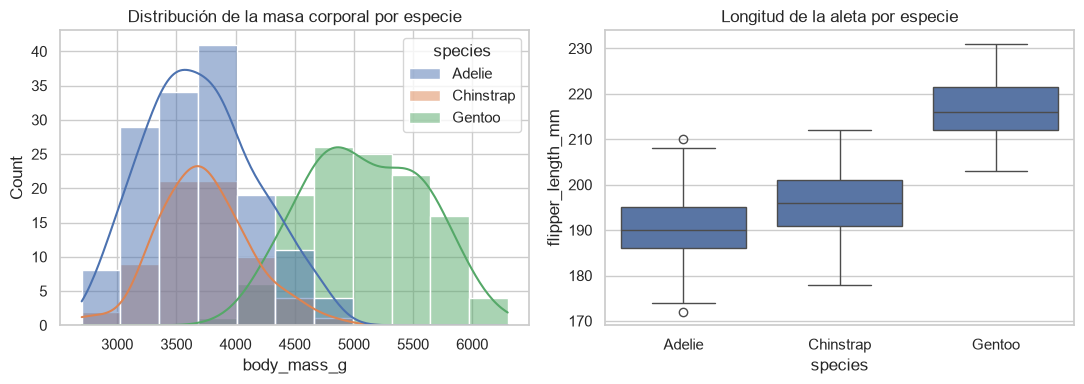

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.histplot(data=penguins, x="body_mass_g", hue="species", kde=True, ax=axes[0])
axes[0].set_title("Distribución de la masa corporal por especie")

sns.boxplot(data=penguins, x="species", y="flipper_length_mm", ax=axes[1])
axes[1].set_title("Longitud de la aleta por especie")

plt.tight_layout()
plt.show()

**Ejercicio:** usando `penguins`, calcula la media y la desviación estándar de `body_mass_g` agrupadas por `island`, y grafica un boxplot que compare `body_mass_g` entre islas. ¿Qué diferencias observas a simple vista?

In [6]:
# Ejercicio: estadística descriptiva
# TODO 1: calcula media y desviación estándar de body_mass_g agrupado por island
# TODO 2: grafica un boxplot de body_mass_g por island

### 2.2 Análisis inferencial

**Definición:** usa una **muestra** para sacar conclusiones sobre una **población**, cuantificando explícitamente la incertidumbre (intervalos de confianza, pruebas de hipótesis, p-valores).

**Ejemplo de preguntas:**
- ¿La diferencia que veo entre dos grupos es "real" o podría deberse al azar?
- ¿En qué rango está el valor poblacional con determinada confianza?

In [7]:
tips = sns.load_dataset("tips").copy()
tips["tip_pct"] = tips["tip"] / tips["total_bill"] * 100
tips.head()

,total_bill,tip,sex,smoker,day,time,size,tip_pct
0,16.99,1.01,Female,No,Sun,Dinner,2,5.945
1,10.34,1.66,Male,No,Sun,Dinner,3,16.054
2,21.01,3.50,Male,No,Sun,Dinner,3,16.659
3,23.68,3.31,Male,No,Sun,Dinner,2,13.978
4,24.59,3.61,Female,No,Sun,Dinner,4,14.681


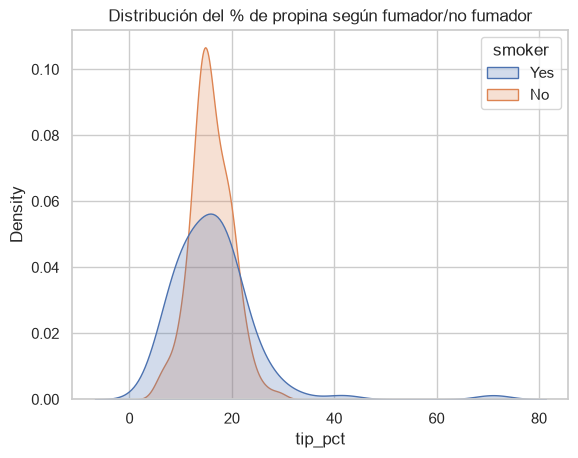

In [8]:
sns.kdeplot(data=tips, x="tip_pct", hue="smoker", fill=True, common_norm=False)
plt.title("Distribución del % de propina según fumador/no fumador")
plt.show()

In [9]:
grupo_fumador = tips.loc[tips["smoker"] == "Yes", "tip_pct"]
grupo_no_fumador = tips.loc[tips["smoker"] == "No", "tip_pct"]

t_stat, p_value = stats.ttest_ind(grupo_fumador, grupo_no_fumador, equal_var=False)
print(f"Diferencia de medias: {grupo_fumador.mean() - grupo_no_fumador.mean():.2f} puntos porcentuales")
print(f"Estadístico t: {t_stat:.3f}")
print(f"p-valor: {p_value:.3f}")

Diferencia de medias: 0.39 puntos porcentuales
Estadístico t: 0.411
p-valor: 0.682


El p-valor y el intervalo de confianza describen la incertidumbre sobre la **población** de clientes de este restaurante (no de "todos los restaurantes del mundo"). Un p-valor alto no prueba que "no hay diferencia"; solo indica que la evidencia muestral no es suficiente para descartar el azar como explicación.

Con p ≈ 0.68 (muy por encima de 0.05), no hay evidencia estadística para concluir que exista una diferencia significativa en tip_pct entre fumadores y no fumadores. Esto no prueba que las medias poblacionales sean iguales; solo indica que la muestra no aporta evidencia suficiente en contra de esa hipótesis. Además, la diferencia observada (0.39 puntos porcentuales) es pequeña en magnitud, así que tampoco sería relevante en la práctica aunque hubiera resultado significativa.

In [10]:
# Intervalo de confianza del 95% para la media de tip_pct (no fumadores)
media = grupo_no_fumador.mean()
sem = stats.sem(grupo_no_fumador)
ic_95 = stats.t.interval(0.95, df=len(grupo_no_fumador) - 1, loc=media, scale=sem)

print(f"Media muestral: {media:.2f}%")
print(f"IC 95%: ({ic_95[0]:.2f}%, {ic_95[1]:.2f}%)")

Media muestral: 15.93%
IC 95%: (15.29%, 16.57%)


El 95% de confianza es una propiedad del procedimiento de estimación, no una probabilidad sobre este intervalo puntual. Lo correcto es decir "si repitiéramos el muestreo muchas veces, el 95% de los intervalos construidos así contendrían la verdadera media poblacional" — no "hay 95% de probabilidad de que la media esté en este rango".

Además, podemos conectar este resultado con la prueba t anterior: la media muestral del grupo fumador cae dentro del IC 95% del grupo no fumador, lo cual refuerza visualmente por qué la prueba t no encontró una diferencia significativa.

Media muestral (fumadores): 16.32%
¿Cae dentro del IC 95% de no fumadores? True


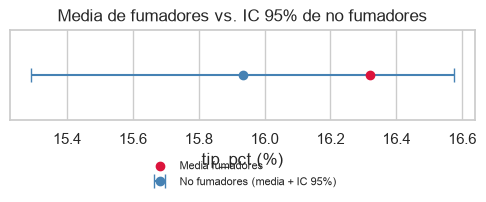

In [11]:
media_fumador = grupo_fumador.mean()
dentro_ic = ic_95[0] <= media_fumador <= ic_95[1]
print(f"Media muestral (fumadores): {media_fumador:.2f}%")
print(f"¿Cae dentro del IC 95% de no fumadores? {dentro_ic}")

fig, ax = plt.subplots(figsize=(6, 2))
ax.errorbar(x=[media], y=[0], xerr=[[media - ic_95[0]], [ic_95[1] - media]],
            fmt="o", capsize=5, color="steelblue", label="No fumadores (media + IC 95%)")
ax.scatter([media_fumador], [0], color="crimson", zorder=5, label="Media fumadores")
ax.set_yticks([])
ax.set_xlabel("tip_pct (%)")
ax.set_title("Media de fumadores vs. IC 95% de no fumadores")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.35), fontsize=8, frameon=False)
fig.subplots_adjust(bottom=0.4, top=0.85)
plt.show()

**Ejercicio:** ¿existe una diferencia estadísticamente significativa en `tip_pct` entre el almuerzo (`Lunch`) y la cena (`Dinner`)? Realiza la prueba t correspondiente e interpreta el resultado.

In [12]:
# Ejercicio: análisis inferencial
# TODO 1: separa tip_pct por time (Lunch / Dinner)
# TODO 2: aplica stats.ttest_ind y comenta el p-valor obtenido

### 2.3 Análisis predictivo

**Definición:** utiliza datos históricos para construir un modelo que **prediga** un valor o categoría para casos nuevos o futuros. Es donde la estadística se conecta directamente con el machine learning.

**Ejemplos de Preguntas:** 
- Dado un caso nuevo (sin la variable objetivo), ¿cuál es mi mejor estimación?
- ¿Qué tan bien generaliza el modelo a datos que no vio durante el entrenamiento?

In [13]:
diamonds = sns.load_dataset("diamonds").sample(2000, random_state=42)
diamonds[["carat", "depth", "table", "price"]].head()

,carat,depth,table,price
1388,0.24,62.1,56.0,559
50052,0.58,60.0,57.0,2201
41645,0.40,62.1,55.0,1238
42377,0.43,60.8,57.0,1304
17244,1.55,62.3,55.0,6901


In [14]:
X = diamonds[["carat"]]
y = diamonds["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

modelo = LinearRegression()
modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)
print(f"R^2 en test: {r2_score(y_test, y_pred):.3f}")

R^2 en test: 0.857


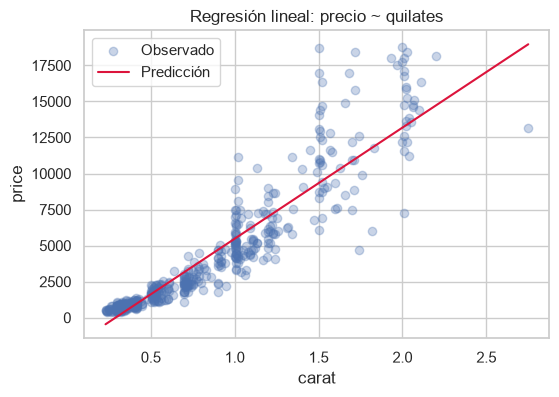

In [15]:
plt.figure(figsize=(6, 4))
plt.scatter(X_test, y_test, alpha=0.3, label="Observado")
orden = X_test["carat"].argsort()
plt.plot(X_test["carat"].values[orden], y_pred[orden], color="crimson", label="Predicción")
plt.xlabel("carat")
plt.ylabel("price")
plt.title("Regresión lineal: precio ~ quilates")
plt.legend()
plt.show()

**Ejercicio 3 (predictivo):** agrega `depth` y/o `table` como predictores adicionales y vuelve a entrenar el modelo. ¿Mejora el R² en test? ¿El modelo sigue siendo razonable para explicar el precio?

In [16]:
# Ejercicio 3: análisis predictivo
# TODO 1: define X con ["carat", "depth", "table"]
# TODO 2: reentrena el modelo y calcula el R^2 en test
# TODO 3: compara con el resultado usando solo "carat"

### Análisis descriptivo vs. inferencial vs. predictivo

| | Descriptivo | Inferencial | Predictivo |
|---|---|---|---|
| Objetivo | Resumir lo observado | Generalizar a la población | Estimar valores nuevos |
| ¿Cuantifica incertidumbre? | No (o mínimamente) | Sí (IC, p-valores) | Sí (métricas de error/validación) |
| Ejemplo en este notebook | `describe()`, boxplots de pingüinos | prueba t sobre `tip_pct` | regresión lineal sobre `price` |
| Riesgo típico | Confundir patrón con conclusión | Mal uso/interpretación del p-valor | Sobreajuste (overfitting) |

## 3. Tipos de datos

Clasificar correctamente una variable es clave porque determina **qué estadísticos y gráficos tienen sentido** (p. ej. no tiene sentido calcular el "promedio" de un código postal).

<figure>
  <img src="https://cdn.prod.website-files.com/6584d3c7e9c648618ca2ec43/66b5e3b5e6d6a9bfacaa3c30_AD_4nXetDuXkiUtVC0iA_3NQryNFQei8UJBP1nh0G3qeA3hGUgHeb9g4PbQxFhemRGsfjXFY1qIg7-5RkuQFmk73UPEA52zY8ax3pyrzUMKUvfdcidK0tUu85MawkXkhqJuBEup9k5jmNsn-5DZd0VkmilCuxoeh.jpeg" alt="Taxonomía de tipos de datos" style="opacity: 1; max-width: 400px;">
  <figcaption style="font-size: 0.85em; color: gray;">Fuente: <a href="https://www.formaloo.com/blog/nominal-vs-ordinal-data-whats-the-difference-for-precise-analysis">Nominal vs Ordinal data: What's the difference for precise analysis?</a></figcaption>
</figure>

Trabajemos con un dataset pequeño construido a mano que combina varios tipos de variable:

In [17]:
encuesta = pd.DataFrame({
    "id_cliente": range(1, 9),
    "genero": ["F", "M", "F", "M", "F", "M", "F", "M"],
    "nivel_educativo": ["Bachillerato", "Pregrado", "Maestría", "Doctorado",
                         "Pregrado", "Bachillerato", "Maestría", "Pregrado"],
    "num_compras_mes": [2, 5, 1, 9, 3, 0, 4, 7],
    "gasto_promedio_usd": [45.30, 120.75, 15.00, 302.10, 88.40, 5.20, 150.60, 210.00],
    "temperatura_local_c": [18.2, 22.5, 19.0, 25.3, 21.1, 17.8, 23.4, 20.0],
    "distancia_tienda_km": [1.2, 5.4, 0.3, 12.1, 3.3, 0.0, 7.6, 2.9],
})
encuesta

,id_cliente,genero,nivel_educativo,num_compras_mes,gasto_promedio_usd,temperatura_local_c,distancia_tienda_km
0,1,F,Bachillerato,2,45.30,18.2,1.2
1,2,M,Pregrado,5,120.75,22.5,5.4
2,3,F,Maestría,1,15.00,19.0,0.3
3,4,M,Doctorado,9,302.10,25.3,12.1
4,5,F,Pregrado,3,88.40,21.1,3.3
5,6,M,Bachillerato,0,5.20,17.8,0.0
6,7,F,Maestría,4,150.60,23.4,7.6
7,8,M,Pregrado,7,210.00,20.0,2.9


### 3.1 Cualitativas vs. cuantitativas

| | Cualitativa (categórica) | Cuantitativa (numérica) |
|---|---|---|
| ¿Qué representa? | Una categoría o etiqueta | Una cantidad medible |
| Subtipos | Nominal, Ordinal | Discreta, Continua |
| Ejemplo en `encuesta` | `genero`, `nivel_educativo` | `num_compras_mes`, `gasto_promedio_usd` |
| Estadístico típico | Moda, frecuencia | Media, mediana, desviación estándar |

In [18]:
# pandas infiere tipos "de bajo nivel" (object, int64, float64),
# pero no conoce automáticamente la semántica (nominal, ordinal, discreta, continua)
encuesta.dtypes

id_cliente               int64
genero                     str
nivel_educativo            str
num_compras_mes          int64
gasto_promedio_usd     float64
temperatura_local_c    float64
distancia_tienda_km    float64
dtype: object

### 3.2 Cualitativas: nominal vs. ordinal

- **Nominal**: categorías sin orden natural. Ej.: `genero`, color favorito, tipo de producto.
- **Ordinal**: categorías con un orden natural, pero sin distancias numéricas interpretables entre ellas. Ej.: `nivel_educativo`, estrato socioeconómico, calificación tipo Likert.

In [19]:
# Nominal: no tiene orden, solo se pueden comparar por igualdad
encuesta["genero"] = encuesta["genero"].astype("category")

# Ordinal: se define explícitamente el orden de las categorías
orden_educativo = ["Bachillerato", "Pregrado", "Maestría", "Doctorado"]
tipo_ordinal = pd.CategoricalDtype(categories=orden_educativo, ordered=True)
encuesta["nivel_educativo"] = encuesta["nivel_educativo"].astype(tipo_ordinal)

encuesta.sort_values("nivel_educativo")

,id_cliente,genero,nivel_educativo,num_compras_mes,gasto_promedio_usd,temperatura_local_c,distancia_tienda_km
0,1,F,Bachillerato,2,45.30,18.2,1.2
5,6,M,Bachillerato,0,5.20,17.8,0.0
1,2,M,Pregrado,5,120.75,22.5,5.4
4,5,F,Pregrado,3,88.40,21.1,3.3
7,8,M,Pregrado,7,210.00,20.0,2.9
2,3,F,Maestría,1,15.00,19.0,0.3
6,7,F,Maestría,4,150.60,23.4,7.6
3,4,M,Doctorado,9,302.10,25.3,12.1


In [20]:
# Al ser ordinal, las comparaciones de orden sí tienen sentido:
print((encuesta["nivel_educativo"] > "Pregrado").tolist())

# En cambio, "genero" > "M" no tendría una interpretación válida (es nominal)

[False, False, True, True, False, False, True, False]


**Ejercici:** crea una variable `satisfaccion` para 8 clientes ficticios con categorías `["Muy insatisfecho", "Insatisfecho", "Neutral", "Satisfecho", "Muy satisfecho"]`, y ordénala correctamente usando `pd.CategoricalDtype`.

In [21]:
# Ejercicio 4: variable ordinal
# TODO 1: crea una lista/Series "satisfaccion" con 8 valores tomados de las 5 categorías
# TODO 2: define el CategoricalDtype ordenado correspondiente
# TODO 3: ordena la Serie y verifica que el orden sea el esperado

### 3.3 Cuantitativas: discreta vs. continua

- **Discreta**: resultado de **contar**; toma valores enteros (o un conjunto contable). Ej.: `num_compras_mes`.
- **Continua**: resultado de **medir**; puede tomar cualquier valor dentro de un rango. Ej.: `gasto_promedio_usd`.

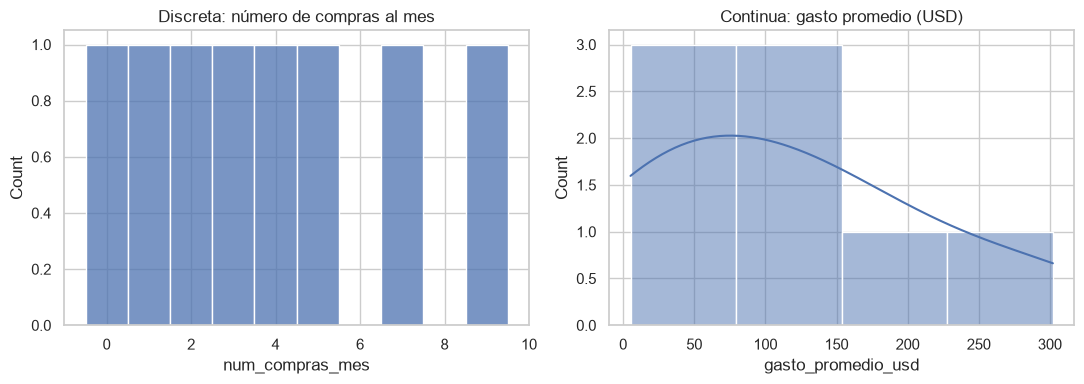

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.histplot(encuesta["num_compras_mes"], discrete=True, ax=axes[0])
axes[0].set_title("Discreta: número de compras al mes")

sns.histplot(encuesta["gasto_promedio_usd"], kde=True, ax=axes[1])
axes[1].set_title("Continua: gasto promedio (USD)")

plt.tight_layout()
plt.show()

**Ejercicio:** de las columnas de `penguins` usadas en la sección 2.1, indica cuáles son discretas y cuáles continuas, y verifica tu respuesta inspeccionando `penguins.dtypes`.

In [23]:
# Ejercicio 5: discreta vs. continua
# TODO: inspecciona penguins.dtypes y clasifica cada variable numérica

### 3.4 Bonus: escalas de medición (nominal, ordinal, intervalo, razón)

La distinción cualitativa/cuantitativa se puede refinar con las **escalas de medición de Stevens**, que explican *por qué* ciertas operaciones son válidas en unos tipos y no en otros:

| Escala | ¿Tiene orden? | ¿Distancias interpretables? | ¿Cero absoluto? | Operaciones válidas | Ejemplo |
|---|---|---|---|---|---|
| Nominal | No | No | No | Moda, frecuencia | Género, color favorito |
| Ordinal | Sí | No | No | Mediana, percentiles, moda | Nivel educativo, estrato |
| Intervalo | Sí | Sí | No | Suma, resta, media | Temperatura en °C, año calendario, puntaje de crédito (350-850) |
| Razón | Sí | Sí | Sí | Todas, incl. razones/multiplicación | Ingreso, distancia, edad, precio, peso, duración, número de hijos |

<figure>
  <img src="https://cdn-cms.orchidsinternationalschool.com/media/fcb4be86-8d4d-4752-ae8d-d99a96a743a4.png" alt="Escalas de medición de Stevens" style="opacity: 1; max-width: 800px;">
  <figcaption style="font-size: 0.85em; color: gray;">Fuente: <a href="https://www.orchidsinternationalschool.com/maths-concepts/scales-of-measurement">Scales of Measurement: Types, Examples, and Uses</a></figcaption>
</figure>

**Ejemplos de por qué importa la diferencia:**

- **Temperatura:** decir que "20 °C es el doble de caliente que 10 °C" es incorrecto (escala de intervalo, sin cero absoluto: 0 °C no significa "ausencia de temperatura"). En Kelvin (escala de razón, con cero absoluto real) sí es válido comparar razones: 20 K sí es el doble de 10 K.
- **Fechas / años calendario:** el año 2020 no es "el doble" del año 1010 — el "año 0" es una convención arbitraria del calendario (gregoriano, y cambia si usas otro calendario), no representa ausencia de tiempo. Por eso una fecha es de escala intervalo. En cambio, la *diferencia* entre dos fechas (una duración, ej. "hace 20 años") sí es una cantidad de razón, porque una duración de 0 sí significa "ningún tiempo transcurrido".
- **Credit score (rango típico 350-850):** decir que un puntaje de 700 es "el doble" de bueno que uno de 350 no tiene sentido — la escala no tiene un cero absoluto real (350 es simplemente el mínimo definido arbitrariamente por el modelo de scoring, no representa "cero crédito"). Es un ejemplo muy común en ciencia de datos aplicada a riesgo crediticio, y conviene tenerlo presente al construir *features* o interpretar coeficientes de un modelo que use esta variable.

**Más ejemplos de escala de razón** (todas tienen cero absoluto y sus razones sí son interpretables): peso, altura, ingreso, distancia recorrida, precio, número de hijos, duración de una llamada, velocidad, número de clics en una página.

In [24]:
celsius = pd.Series([10, 20])
kelvin = celsius + 273.15

print(f"Razón en Celsius (NO válida): {celsius[1] / celsius[0]:.2f}")
print(f"Razón en Kelvin  (sí válida): {kelvin[1] / kelvin[0]:.3f}")

Razón en Celsius (NO válida): 2.00
Razón en Kelvin  (sí válida): 1.035


**Ejercicio:** clasifica las siguientes variables según la escala de Stevens (nominal, ordinal, intervalo o razón) y justifica brevemente: código postal, puesto en una carrera (1º, 2º, 3º...), calificación Likert de 1 a 5, ingreso anual, año de nacimiento.

### 3.5 Resumen y su equivalente en `pandas` / `scikit-learn`

| Tipo de dato | Ejemplo | dtype recomendado en `pandas` | Codificación típica para ML |
|---|---|---|---|
| Nominal | `genero` | `category` (sin orden) | One-hot encoding |
| Ordinal | `nivel_educativo` | `CategoricalDtype(ordered=True)` | Ordinal encoding (respetando el orden) |
| Discreta | `num_compras_mes` | `int64` | Tal cual, o discretizada en bins |
| Continua | `gasto_promedio_usd` | `float64` | Tal cual, o escalada/normalizada |

![Mapa mental resumen de tipos de datos](images/resumen_tipos_datos.png)
<!-- TODO(nico): reemplazar por un mapa mental que integre las secciones 3.1 a 3.4 en un solo esquema -->

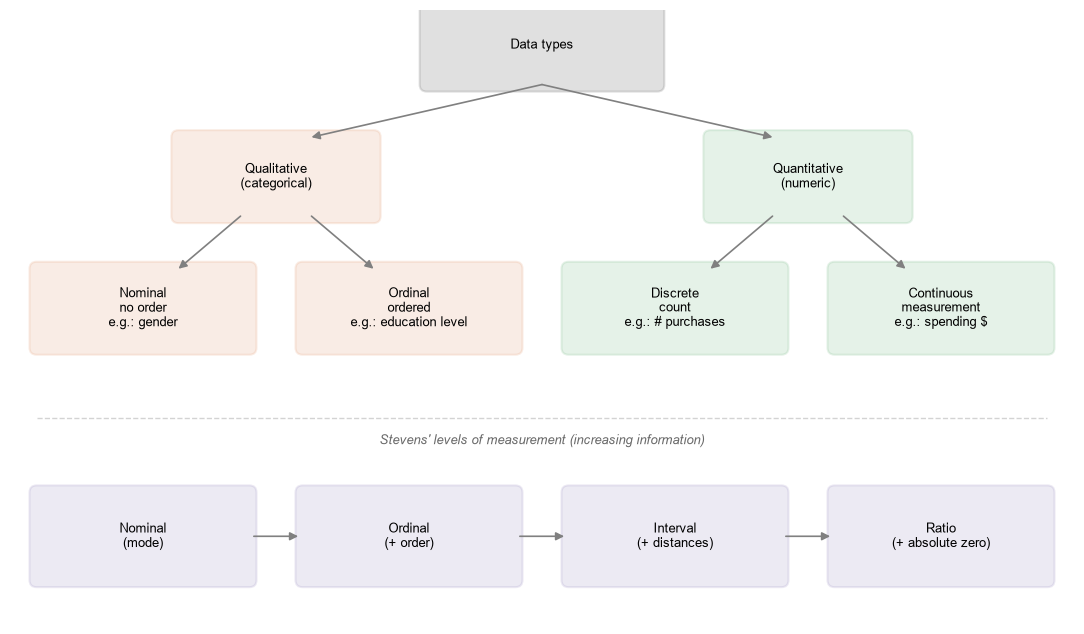

In [52]:
from matplotlib.patches import FancyBboxPatch

def caja(ax, xy, texto, color="#4C72B0", ancho=2.2, alto=0.9, fontsize=9):
    x, y = xy
    box = FancyBboxPatch(
        (x - ancho / 2, y - alto / 2), ancho, alto,
        boxstyle="round,pad=0.08,rounding_size=0.08",
        linewidth=1.5, edgecolor=color, facecolor=color, alpha=0.15,
    )
    ax.add_patch(box)
    ax.text(x, y, texto, ha="center", va="center", fontsize=fontsize, color="black")

def flecha(ax, origen, destino):
    ax.annotate("", xy=destino, xytext=origen,
                arrowprops=dict(arrowstyle="-|>", color="gray", lw=1.2, shrinkA=0, shrinkB=0))

fig, ax = plt.subplots(figsize=(11, 6.5))
ax.set_xlim(0, 12)
ax.set_ylim(0, 7)
ax.axis("off")

# Nivel 0: raíz
caja(ax, (6, 6.6), "Data types", color="#333333", ancho=2.6)

# Nivel 1
caja(ax, (3, 5.1), "Qualitative\n(categorical)", color="#DD8452")
caja(ax, (9, 5.1), "Quantitative\n(numeric)", color="#55A868")
flecha(ax, (6, 6.15), (3.4, 5.55))
flecha(ax, (6, 6.15), (8.6, 5.55))

# Nivel 2
caja(ax, (1.5, 3.6), "Nominal\nno order\ne.g.: gender", color="#DD8452", ancho=2.4)
caja(ax, (4.5, 3.6), "Ordinal\nordered\ne.g.: education level", color="#DD8452", ancho=2.4)
caja(ax, (7.5, 3.6), "Discrete\ncount\ne.g.: # purchases", color="#55A868", ancho=2.4)
caja(ax, (10.5, 3.6), "Continuous\nmeasurement\ne.g.: spending $", color="#55A868", ancho=2.4)

flecha(ax, (2.6, 4.65), (1.9, 4.05))
flecha(ax, (3.4, 4.65), (4.1, 4.05))
flecha(ax, (8.6, 4.65), (7.9, 4.05))
flecha(ax, (9.4, 4.65), (10.1, 4.05))

# Separador visual
ax.plot([0.3, 11.7], [2.35, 2.35], color="lightgray", lw=1, linestyle="--")
ax.text(6, 2.05, "Stevens\' levels of measurement (increasing information)",
        ha="center", fontsize=9, style="italic", color="dimgray")

# Nivel 3: escalera de Stevens
escalones = ["Nominal", "Ordinal", "Interval", "Ratio"]
detalles = ["mode", "+ order", "+ distances", "+ absolute zero"]
xs = [1.5, 4.5, 7.5, 10.5]
for x, nombre, detalle in zip(xs, escalones, detalles):
    caja(ax, (x, 1.0), f"{nombre}\n({detalle})", color="#8172B2", ancho=2.4, alto=1.0)
for x1, x2 in zip(xs[:-1], xs[1:]):
    flecha(ax, (x1 + 1.25, 1.0), (x2 - 1.25, 1.0))

plt.tight_layout()
plt.show()


## 4. Cierre

**Ideas clave de hoy:**

- La estadística es el componente que da rigor y cuantifica incertidumbre en un proyecto de ciencia de datos.
- El análisis descriptivo, inferencial y predictivo responden preguntas distintas. En la práctica es común que se **encadenen** dentro de un mismo proyecto (primero explorar, luego validar si un patrón es real, y después predecir), aunque no es una regla estricta.
- Clasificar correctamente una variable (nominal/ordinal/discreta/continua, o su escala de medición) determina qué estadísticos, gráficos y modelos son válidos.